In [1]:
import matplotlib.pyplot as plt
import math
import csv
import pandas as pd
import numpy as np

global Ts 
Ts = 0.00005   #1/200000
global Vdc 
Vdc = 24
global pi 
pi = 180

global Iterm
Iterm = 0

global Ki
global Kp
Ki = 0.05
Kp = 0.002

In [2]:
def rtd(degree):
    return math.degrees(degree)
def dtr(radian):
    return math.radians(radian)


In [3]:
def clarketf(a, b, c):
    alpha = (2/3)*(a - 0.5*b - 0.5*c)
    beta =(2/3)*(math.sqrt(3)*(1/2)*b - math.sqrt(3)*(1/2)*c)
    output = [alpha, beta]
    return output

theta_elec = 0

a = math.sin(dtr(theta_elec))*Vdc
b = math.sin(dtr(theta_elec+120))*Vdc
c = math.sin(dtr(theta_elec+240))*Vdc

print(a)
print(b)
print(c)

clarke = clarketf(a,b,c)
print(clarke[0])
print(clarke[1])


0.0
20.784609690826528
-20.784609690826525
-1.1842378929335002e-15
24.0


$\begin{vmatrix} i_{\alpha} \\ i_{\beta} \end{vmatrix} = \frac{2}{3}\begin{vmatrix} 1\; -\frac{1}{2}\; -\frac{1}{2} \\ 0\;   \frac{\sqrt{3}}{2}\; -\frac{\sqrt{3}}{2}  \end{vmatrix} \begin{vmatrix} i_{U} \\ i_{V} \\ i_{W} \end{vmatrix} $

In [4]:
def thetacalc(alpha, beta):
    
    alpha_abs = abs(alpha)
    
    beta_abs = abs(beta)
    
    alphasign = 1
    betasign = 1
    
    if alpha < 0: 
        alphasign = -1
    else :
        alphasign = 1
        
    if beta < 0:
        betasign = -1
    else: 
        betasign = 1
        
    # 0<=theta<45    
    if alphasign == 1 and betasign == 1:
        if alpha_abs > beta_abs: #1
            theta = rtd(math.atan(beta/alpha))
            return theta
        elif alpha_abs < beta_abs: #2
            theta = 90 - rtd(math.atan(alpha/beta))
            return theta
        elif beta_abs == 0:
            thata = 0
            return theta
        elif beta_abs == alpha_abs:
            theta = 45
            return theta
      
    # 90<=theta<180
    elif alphasign == -1 and betasign == 1:
        if alpha_abs > beta_abs: #4
            theta = 180 - rtd(math.atan(beta/alpha_abs))
            return theta
        elif alpha_abs < beta_abs: #3
            theta = 90 + rtd(math.atan(alpha_abs/beta))
            return theta
        elif alpha_abs == 0:
            thata = 90
            return theta
        elif alpha_abs == beta_abs:
            theta = 135
            return theta

    # 180<=theta<270
    elif alphasign == -1 and betasign == -1:
        if alpha_abs > beta_abs: #5
            theta = 180 + rtd(math.atan(beta_abs/alpha_abs))
            return theta
        elif alpha_abs < beta_abs: #6
            theta = 270 - rtd(math.atan(alpha_abs/beta_abs))
            return theta
        elif beta_abs == 0:
            thata = 180
            return theta
        elif alpha_abs == beta_abs:
            theta = 225
            return theta

    # 270<=theta<360
    elif alphasign == 1 and betasign == -1:
        if alpha_abs > beta_abs: #8
            theta = 360 - rtd(math.atan(beta_abs/alpha_abs))
            return theta
        elif alpha_abs < beta_abs: #7
            theta = 270 + rtd(math.atan(alpha_abs/beta_abs))
            return theta
        elif alpha_abs == 0:
            thata = 270
            return theta
        elif alpha_abs == beta_abs:
            theta = 315
            return theta
        
print(clarke[0])
print(clarke[1])

alpha = clarke[0]
beta = clarke[1]

theta = thetacalc(alpha, beta)
print(theta)

    

-1.1842378929335002e-15
24.0
90.0


$\theta = \tan^{-1}(\frac{|\alpha|}{|\beta|})$

In [5]:
def parktf(alpha, beta, theta):
    d = math.cos(dtr(theta))*alpha + math.sin(dtr(theta))*beta*-1
    q = math.sin(dtr(theta))*alpha + math.cos(dtr(theta))*beta
    
    output = [d,q]
    return output

park = parktf(alpha, beta, theta)
print(park)

[-24.0, 2.853382660433235e-16]


In [6]:
def PIctrl(ref, feedback):
    error = ref - feedback
    
    return 0

In [26]:
def svm_tcalc(theta, vref):

    
    vref = abs(vref)
    N = 0
    
    if theta>=0 and theta<60:
        n = 1
    elif theta>=60 and theta<120:
        n = 2
    elif theta>=120 and theta<180:
        n = 3
    elif theta>=180 and theta<240:
        n = 4
    elif theta>=240 and theta<300:
        n = 5
    elif theta>=300 and theta<360:
        n = 6
    
    if n == 1:
        N = 6
    else:
        N = n-1
        
    
    T1 = (math.sqrt(3)*Ts*vref)/Vdc*math.sin(dtr(n*60-theta))
    T2 = math.sqrt(3)*Ts*vref/Vdc*math.sin(dtr(theta-(N-1)*60))
    T0 = Ts - (T1+T2)
    
    flag = 0
    
    if T0 < 0:
        flag = 1
    else:
        flag = 0
    
    result = [T1, T2, T0, flag]
    
    return result

vref = park[1]
print(theta)
svm_time = svm_tcalc(theta, vref)

print(svm_time)
    
    

91.0
[1.4652813591718194e-06, 3.0219247484799414e-06, 4.5512793892348244e-05, 0]


$T_{1} = \frac{\sqrt{3} \cdot T_{S} \cdot |V_{ref}|}{V_{dc}}  \sin(\frac{n}{3}\pi - \alpha)$

$T_{2} = \frac{\sqrt{3} \cdot T_{S} \cdot |V_{ref}|}{V_{dc}}  \sin(\alpha - \frac{n-1}{3}\pi)$

$T_{0} = T_{S} - (T_{1}+T_{2})$

In [76]:
degree = 0

f = open('data.csv', 'w', encoding='utf-8', newline='')
wr = csv.writer(f)
wr.writerow(['T1', 'T2', 'T0', 'flag' ,'vref', 'theta', 'alpha', 'beta'])

while degree < 360:
    theta_elec = degree

    degree = degree + 1
    
    a = math.sin(dtr(theta_elec))*Vdc/5
    b = math.sin(dtr(theta_elec+120))*Vdc/5
    c = math.sin(dtr(theta_elec+240))*Vdc/5
    
    clarke = clarketf(a,b,c)
    
    alpha = clarke[0]
    beta = clarke[1]
    
    theta = thetacalc(alpha, beta)
    
    park = parktf(alpha, beta, theta)
    
    vref = math.sqrt(alpha*alpha+beta*beta)
    
    svm_time = svm_tcalc(theta, vref)
    
    wr.writerow([svm_time[0],svm_time[1],svm_time[2],svm_time[3], park[1], theta, alpha, beta])
    
f.close()



In [77]:
df1 = pd.read_csv("data.csv", encoding = 'utf-8')
print(df1.columns)
print(df1.head())
print()
print(df1.info())

print("--------------------")

degrees = np.arange(0,360,1)




Index(['T1', 'T2', 'T0', 'flag', 'vref', 'theta', 'alpha', 'beta'], dtype='object')
         T1        T2        T0  flag          vref  theta         alpha  \
0  0.000009  0.000017  0.000024     0 -2.144241e-18   90.0 -2.960595e-16   
1  0.000009  0.000017  0.000024     0  1.675176e-01   89.0  8.377155e-02   
2  0.000009  0.000017  0.000024     0  3.348311e-01   88.0  1.675176e-01   
3  0.000009  0.000017  0.000023     0  5.017366e-01   87.0  2.512126e-01   
4  0.000010  0.000017  0.000023     0  6.680309e-01   86.0  3.348311e-01   

       beta  
0  4.800000  
1  4.799269  
2  4.797076  
3  4.793422  
4  4.788307  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T1      360 non-null    float64
 1   T2      360 non-null    float64
 2   T0      360 non-null    float64
 3   flag    360 non-null    int64  
 4   vref    360 non-null    float64
 5   theta 

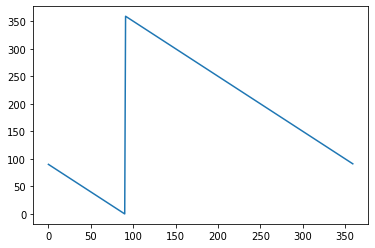

In [78]:
thetalist = df1.loc[:,"theta"]
plt.plot(thetalist)

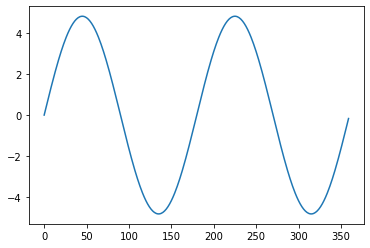

In [79]:
vreflist = df1.loc[:,"vref"]
plt.plot(vreflist)

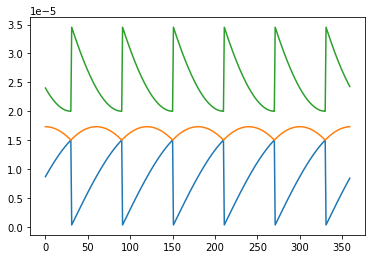

In [80]:
T1list = df1.loc[:,"T1"]
T2list = df1.loc[:,"T2"]
T0list = df1.loc[:,"T0"]
plt.plot(T1list)
plt.plot(T2list)
plt.plot(T0list)

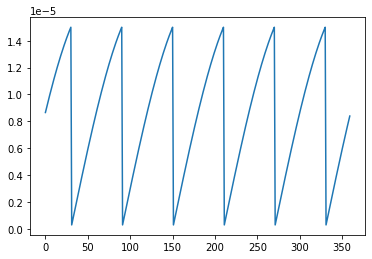

In [84]:
plt.plot(T1list)

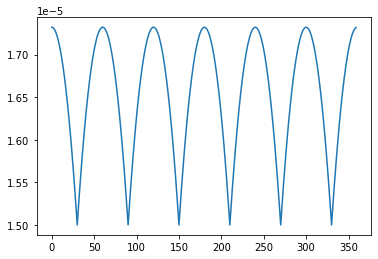

In [85]:
plt.plot(T2list)

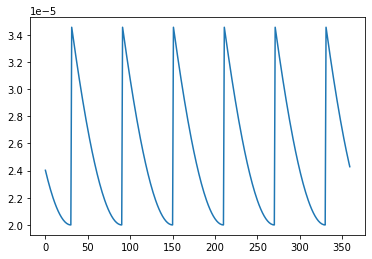

In [86]:
plt.plot(T0list)

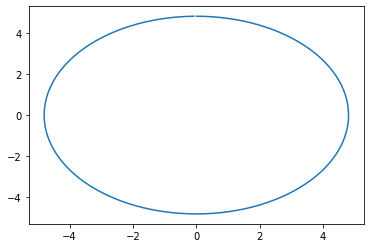

In [87]:
alphalist = df1.loc[:,"alpha"]
betalist = df1.loc[:,"beta"]

plt.plot(alphalist, betalist)

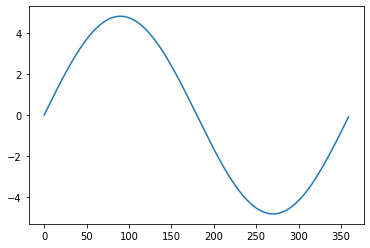

In [88]:
plt.plot(alphalist)

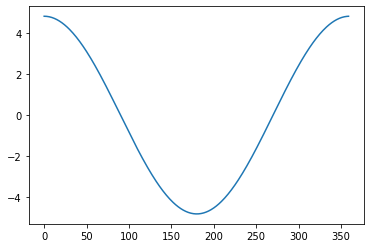

In [89]:
plt.plot(betalist)

In [90]:
MI = abs(vref)/(2/3.14*Vdc)
print(MI)

0.3139999999999999
